24BAD090 PRAVEENKUMAR G


In [5]:
import os

print("Dataset path:")
print(path)

print("\nFolders and files:")

for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)

    indent = "  " * level

    print(indent + os.path.basename(root) + "/")

    for file in files[:5]:
        print(indent + "  " + file)

    if level >= 2:
        dirs[:] = []

Dataset path:
/root/.cache/kagglehub/datasets/mahmudulhaqueshawon/catcat/versions/3

Folders and files:
3/
  train/
    dogs/
      dog_15.jpg
      dog_492.jpg
      dog_77.jpg
      dog_13.jpg
      dog_188.jpg
    cats/
      cat_66.jpg
      cat_452.jpg
      cat_146.jpg
      cat_34.jpg
      cat_265.jpg
  test/
    cat_s/
      cat_244.jpg
      cat_116.jpg
      cat_56.jpg
      cat_118.jpg
      cat_538.jpg
    dogs/
      dog_191.jpg
      dog_44.jpg
      dog_519.jpg
      dog_517.jpg
      dog_194.jpg


24BAD090 (PRAVEEN KUMAR)


Training folder: /root/.cache/kagglehub/datasets/mahmudulhaqueshawon/catcat/versions/3/train
Testing folder : /root/.cache/kagglehub/datasets/mahmudulhaqueshawon/catcat/versions/3/test

Renamed 'cat_s' to 'cats'.

Training classes:
['dogs', 'cats']

Testing classes:
['dogs', 'cats']
Found 555 images belonging to 2 classes.
Found 138 images belonging to 2 classes.
Found 445 images belonging to 2 classes.
Found 110 images belonging to 2 classes.

DATASET INFORMATION
Training images   : 445
Validation images : 110
Testing images    : 138
Classes           : {'cats': 0, 'dogs': 1}


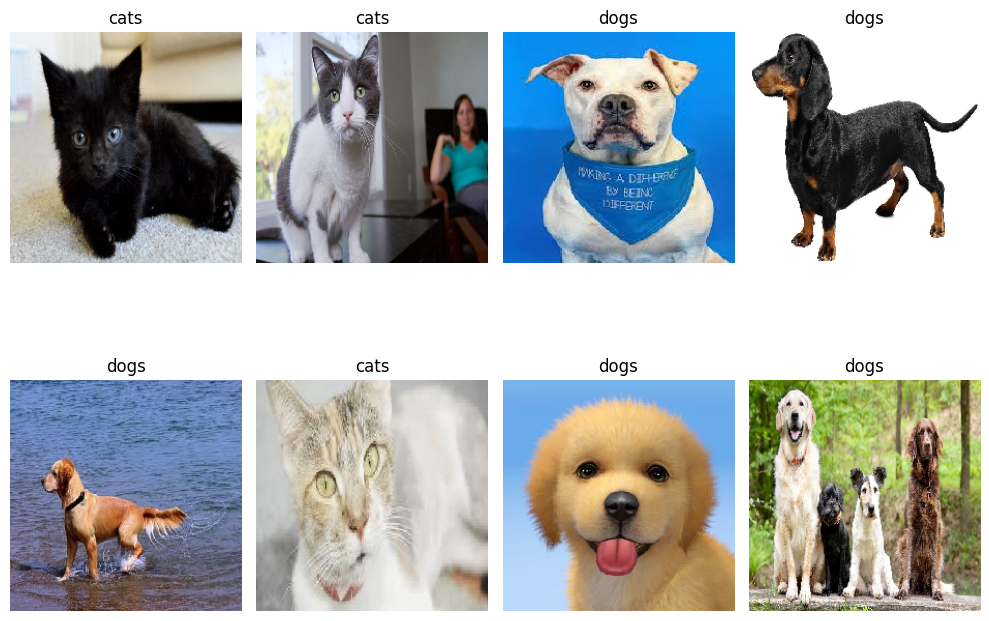


PART A COMPLETED SUCCESSFULLY!


In [6]:
# ============================================================
# PART A: DATASET PREPARATION
# Fast Version
# ============================================================

import os
import shutil
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator


# ------------------------------------------------------------
# 1. Dataset Paths
# ------------------------------------------------------------

TRAIN_DIR = os.path.join(path, "train")
TEST_DIR = os.path.join(path, "test")

print("Training folder:", TRAIN_DIR)
print("Testing folder :", TEST_DIR)


# ------------------------------------------------------------
# 2. Fix Test Folder Name
# ------------------------------------------------------------

# Training class = cats
# Test class = cat_s
# Rename cat_s to cats

old_cat_folder = os.path.join(TEST_DIR, "cat_s")
new_cat_folder = os.path.join(TEST_DIR, "cats")

if os.path.exists(old_cat_folder):

    os.rename(
        old_cat_folder,
        new_cat_folder
    )

    print("\nRenamed 'cat_s' to 'cats'.")


# ------------------------------------------------------------
# 3. Display Dataset Classes
# ------------------------------------------------------------

print("\nTraining classes:")
print(os.listdir(TRAIN_DIR))

print("\nTesting classes:")
print(os.listdir(TEST_DIR))


# ------------------------------------------------------------
# 4. Image Settings
# ------------------------------------------------------------

IMG_SIZE = (224, 224)

BATCH_SIZE = 64


# ------------------------------------------------------------
# 5. Image Preprocessing
# ------------------------------------------------------------

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)


# ------------------------------------------------------------
# 6. Load Training Dataset
# ------------------------------------------------------------

train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=True
)


# ------------------------------------------------------------
# 7. Load Test Dataset
# ------------------------------------------------------------

test_data = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)


# ------------------------------------------------------------
# 8. Create Validation Split
# ------------------------------------------------------------

# We will use 20% of training data as validation data.

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)


val_train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)


# Reload training data with validation split

train_data = val_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    subset="training",
    shuffle=True
)


val_data = val_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    subset="validation",
    shuffle=False
)


# ------------------------------------------------------------
# 9. Dataset Information
# ------------------------------------------------------------

print("\n======================================")
print("DATASET INFORMATION")
print("======================================")

print(
    "Training images   :",
    train_data.samples
)

print(
    "Validation images :",
    val_data.samples
)

print(
    "Testing images    :",
    test_data.samples
)

print(
    "Classes           :",
    train_data.class_indices
)


# ------------------------------------------------------------
# 10. Display Sample Images
# ------------------------------------------------------------

images, labels = next(train_data)

class_names = [
    name
    for name, index in sorted(
        train_data.class_indices.items(),
        key=lambda x: x[1]
    )
]


plt.figure(figsize=(10, 8))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    plt.imshow(images[i])

    plt.title(
        class_names[int(labels[i])]
    )

    plt.axis("off")

plt.tight_layout()

plt.show()


print("\nPART A COMPLETED SUCCESSFULLY!")

In [7]:
# ============================================================
# PART B: TRANSFER LEARNING USING RESNET-50
# ============================================================

import tensorflow as tf

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import (
    Dense,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Model


# ------------------------------------------------------------
# 1. Load Pre-trained ResNet-50
# ------------------------------------------------------------

print("Loading ResNet-50...")

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("ResNet-50 loaded successfully!")


# ------------------------------------------------------------
# 2. Freeze Feature Extraction Layers
# ------------------------------------------------------------

base_model.trainable = False


# ------------------------------------------------------------
# 3. Add New Classification Layers
# ------------------------------------------------------------

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    64,
    activation="relu"
)(x)

output = Dense(
    2,
    activation="softmax"
)(x)


# ------------------------------------------------------------
# 4. Create Final Model
# ------------------------------------------------------------

model = Model(
    inputs=base_model.input,
    outputs=output
)


# ------------------------------------------------------------
# 5. Compile Model
# ------------------------------------------------------------

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# ------------------------------------------------------------
# 6. Display Model Information
# ------------------------------------------------------------

print("\n======================================")
print("MODEL INFORMATION")
print("======================================")

print("Model: ResNet-50")
print("Number of classes: 2")
print("Input size: 224 x 224 x 3")
print("Pre-trained weights: ImageNet")
print("Feature layers frozen: Yes")
print("Loss: Sparse Categorical Crossentropy")
print("Optimizer: Adam")


# ------------------------------------------------------------
# 7. Count Trainable Parameters
# ------------------------------------------------------------

trainable_parameters = np.sum([
    np.prod(v.shape)
    for v in model.trainable_weights
])

print(
    "\nTrainable parameters:",
    trainable_parameters
)

print("\nPART B COMPLETED SUCCESSFULLY!")

Loading ResNet-50...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet-50 loaded successfully!

MODEL INFORMATION
Model: ResNet-50
Number of classes: 2
Input size: 224 x 224 x 3
Pre-trained weights: ImageNet
Feature layers frozen: Yes
Loss: Sparse Categorical Crossentropy
Optimizer: Adam

Trainable parameters: 131266

PART B COMPLETED SUCCESSFULLY!


Starting model training...
Epoch 1/2
7/7 ━━━━━━━━━━━━━━━━━━━━ 134s 19s/step - accuracy: 0.5011 - loss: 0.7273 - val_accuracy: 0.5000 - val_loss: 0.7073
Epoch 2/2
7/7 ━━━━━━━━━━━━━━━━━━━━ 130s 17s/step - accuracy: 0.5191 - loss: 0.6937 - val_accuracy: 0.5000 - val_loss: 0.6929

Evaluating test dataset...
3/3 ━━━━━━━━━━━━━━━━━━━━ 26s 7s/step - accuracy: 0.5000 - loss: 0.6826

FINAL RESULTS
Training Accuracy   : 51.91%
Validation Accuracy : 50.00%
Training Loss       : 0.6937
Validation Loss     : 0.6929
Test Accuracy       : 50.00%
Test Loss           : 0.6826


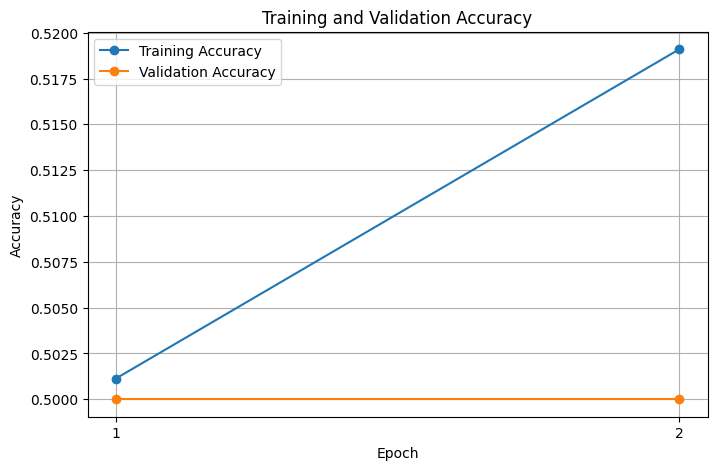

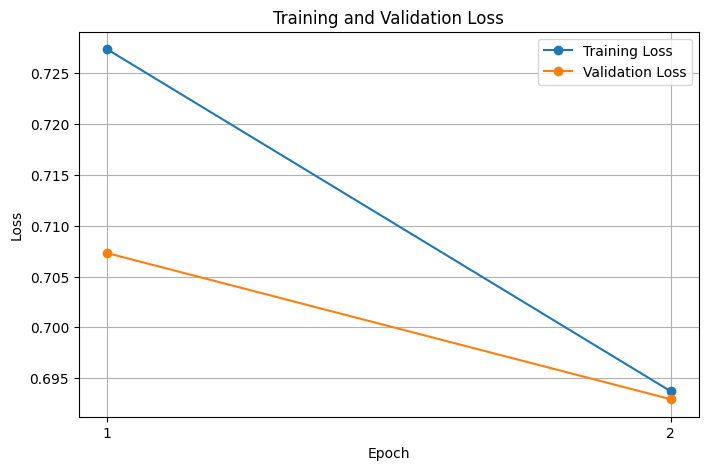


EPOCH-WISE RESULTS
Epoch 1 | Training Accuracy: 50.11% | Validation Accuracy: 50.00% | Training Loss: 0.7273 | Validation Loss: 0.7073
Epoch 2 | Training Accuracy: 51.91% | Validation Accuracy: 50.00% | Training Loss: 0.6937 | Validation Loss: 0.6929

PART C COMPLETED SUCCESSFULLY!


In [8]:
# ============================================================
# PART C: MODEL TRAINING AND PERFORMANCE EVALUATION
# FAST VERSION
# ============================================================

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Train the Model
# ------------------------------------------------------------

print("Starting model training...")

EPOCHS = 2

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)


# ------------------------------------------------------------
# 2. Get Training Results
# ------------------------------------------------------------

train_accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]


# ------------------------------------------------------------
# 3. Evaluate on Test Dataset
# ------------------------------------------------------------

print("\nEvaluating test dataset...")

test_loss, test_accuracy = model.evaluate(
    test_data,
    verbose=1
)


# ============================================================
# 4. Display Results
# ============================================================

print("\n======================================")
print("FINAL RESULTS")
print("======================================")

print(
    "Training Accuracy   : {:.2f}%".format(
        train_accuracy[-1] * 100
    )
)

print(
    "Validation Accuracy : {:.2f}%".format(
        val_accuracy[-1] * 100
    )
)

print(
    "Training Loss       : {:.4f}".format(
        train_loss[-1]
    )
)

print(
    "Validation Loss     : {:.4f}".format(
        val_loss[-1]
    )
)

print(
    "Test Accuracy       : {:.2f}%".format(
        test_accuracy * 100
    )
)

print(
    "Test Loss           : {:.4f}".format(
        test_loss
    )
)


# ============================================================
# 5. Accuracy vs Epoch
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    train_accuracy,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_accuracy,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title(
    "Training and Validation Accuracy"
)

plt.xticks(
    range(1, EPOCHS + 1)
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 6. Loss vs Epoch
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    train_loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_loss,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Training and Validation Loss"
)

plt.xticks(
    range(1, EPOCHS + 1)
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 7. Epoch-wise Results
# ============================================================

print("\n======================================")
print("EPOCH-WISE RESULTS")
print("======================================")

for i in range(EPOCHS):

    print(
        "Epoch {} | "
        "Training Accuracy: {:.2f}% | "
        "Validation Accuracy: {:.2f}% | "
        "Training Loss: {:.4f} | "
        "Validation Loss: {:.4f}".format(
            i + 1,
            train_accuracy[i] * 100,
            val_accuracy[i] * 100,
            train_loss[i],
            val_loss[i]
        )
    )


print("\nPART C COMPLETED SUCCESSFULLY!")

Loading Hugging Face model...


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Hugging Face model loaded successfully!

SAMPLE IMAGE
Actual Class: cats


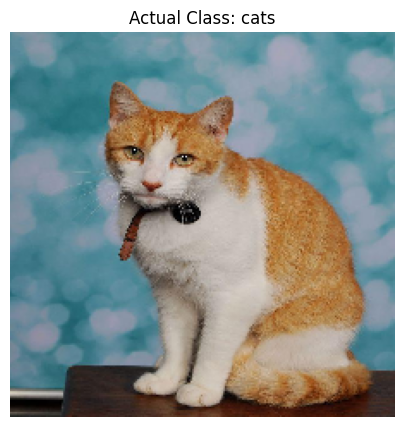


HUGGING FACE PREDICTION
tiger cat : 33.75%
Egyptian cat : 29.40%
tabby, tabby cat : 17.13%
bow tie, bow-tie, bowtie : 2.78%
Siamese cat, Siamese : 0.90%

Top Prediction:
Class: tiger cat
Confidence: 33.75%

RESNET-50 PREDICTION
Class: dogs
Confidence: 52.63%

RESNET-50 CLASS PROBABILITIES
cats : 47.37%
dogs : 52.63%

MODEL COMPARISON
Actual Class: cats

ResNet-50: dogs
Confidence: 52.63%

Hugging Face ViT: tiger cat
Confidence: 33.75%


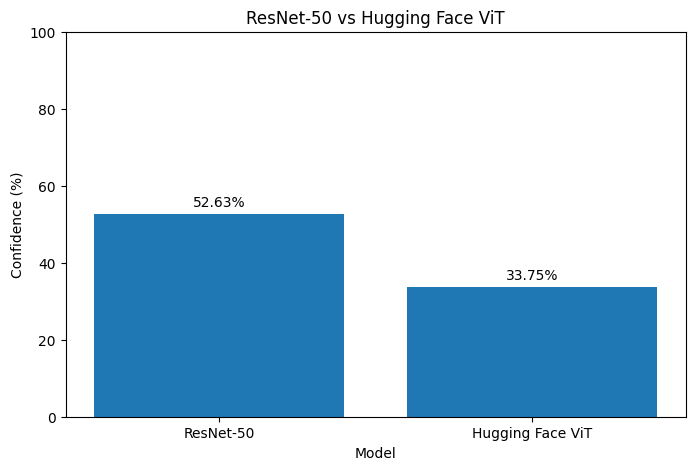

In [9]:
# ============================================================
# PART D: HUGGING FACE PRE-TRAINED VISION MODEL
# ============================================================

!pip install -q transformers

from transformers import pipeline
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Load Hugging Face Model
# ============================================================

print("Loading Hugging Face model...")

hf_classifier = pipeline(
    "image-classification",
    model="google/vit-base-patch16-224"
)

print("Hugging Face model loaded successfully!")


# ============================================================
# 2. Get One Image from Test Dataset
# ============================================================

test_images, test_labels = next(test_data)

sample_image = test_images[0]

actual_label_index = int(test_labels[0])


# ============================================================
# 3. Get Class Names
# ============================================================

class_names = [
    name
    for name, index in sorted(
        test_data.class_indices.items(),
        key=lambda x: x[1]
    )
]

actual_class = class_names[
    actual_label_index
]


print("\n======================================")
print("SAMPLE IMAGE")
print("======================================")

print("Actual Class:", actual_class)


# ============================================================
# 4. Convert Image for Hugging Face
# ============================================================

image_array = (
    sample_image * 255
).astype(np.uint8)

image = Image.fromarray(
    image_array
)


# ============================================================
# 5. Display Image
# ============================================================

plt.figure(figsize=(5, 5))

plt.imshow(image)

plt.title(
    "Actual Class: " + actual_class
)

plt.axis("off")

plt.show()


# ============================================================
# 6. Hugging Face Prediction
# ============================================================

hf_results = hf_classifier(image)


print("\n======================================")
print("HUGGING FACE PREDICTION")
print("======================================")


for result in hf_results[:5]:

    print(
        "{} : {:.2f}%".format(
            result["label"],
            result["score"] * 100
        )
    )


# ============================================================
# 7. Top Hugging Face Prediction
# ============================================================

hf_label = hf_results[0]["label"]

hf_confidence = hf_results[0]["score"]


print("\nTop Prediction:")

print(
    "Class:",
    hf_label
)

print(
    "Confidence: {:.2f}%".format(
        hf_confidence * 100
    )
)


# ============================================================
# 8. ResNet-50 Prediction
# ============================================================

resnet_input = np.expand_dims(
    sample_image,
    axis=0
)


resnet_prediction = model.predict(
    resnet_input,
    verbose=0
)


# ============================================================
# 9. Get ResNet Prediction
# ============================================================

predicted_index = np.argmax(
    resnet_prediction[0]
)

resnet_class = class_names[
    predicted_index
]

resnet_confidence = np.max(
    resnet_prediction[0]
)


print("\n======================================")
print("RESNET-50 PREDICTION")
print("======================================")

print(
    "Class:",
    resnet_class
)

print(
    "Confidence: {:.2f}%".format(
        resnet_confidence * 100
    )
)


# ============================================================
# 10. Display ResNet Probabilities
# ============================================================

print("\n======================================")
print("RESNET-50 CLASS PROBABILITIES")
print("======================================")


for i, probability in enumerate(
    resnet_prediction[0]
):

    print(
        "{} : {:.2f}%".format(
            class_names[i],
            probability * 100
        )
    )


# ============================================================
# 11. Model Comparison
# ============================================================

print("\n======================================")
print("MODEL COMPARISON")
print("======================================")

print(
    "Actual Class:",
    actual_class
)

print(
    "\nResNet-50:",
    resnet_class
)

print(
    "Confidence: {:.2f}%".format(
        resnet_confidence * 100
    )
)

print(
    "\nHugging Face ViT:",
    hf_label
)

print(
    "Confidence: {:.2f}%".format(
        hf_confidence * 100
    )
)


# ============================================================
# 12. Confidence Comparison Graph
# ============================================================

models = [
    "ResNet-50",
    "Hugging Face ViT"
]

confidence_values = [
    resnet_confidence * 100,
    hf_confidence * 100
]


plt.figure(figsize=(8, 5))

bars = plt.bar(
    models,
    confidence_values
)

plt.xlabel("Model")

plt.ylabel("Confidence (%)")

plt.title(
    "ResNet-50 vs Hugging Face ViT"
)

plt.ylim(0, 100)


for bar, value in zip(
    bars,
    confidence_values
):

    plt.text(
        bar.get_x() +
        bar.get_width() / 2,
        value + 2,
        "{:.2f}%".format(value),
        ha="center"
    )


plt.show()


